# Clustering

Pyhton Package dealing with machine learning techniques: Sklearn (https://scikit-learn.org/stable/)

Looking for clustering (in other words, looking for similarity or dissimilarity in datasets) is one of the techniques of data mining process.

Clustering, partitioning and classification are critically important operations in the scientific interpretation of observed dataset. These procedures are important components of modern data mining and machine learning. They provide a taxonomy of subpopulations which can then be individually studied, both statistically using multivariate analysis and developing a physical understanding.


The datasets we consider here consist of n objects with p properties. We further assume that the dataset includes members from k subpopulations with distinct locations or patterns in p-space.

### Supervised clustering

- When a training set of well-studied objects is available to characterize the groupings in the dataset, discrimination rules are established on the training set and they are applied to a new test set. These two steps are together called supervised classification.



![Screenshot%202023-11-07%20at%201.12.37%20PM.png](attachment:Screenshot%202023-11-07%20at%201.12.37%20PM.png)

### Unsupervised clustering

- When the number, location, size and morphologies of the groupings are unknown, unsupervised clustering techniques search for groupings in a multivariate dataset based on the proximity of objects using some distance measure in k-space.


For both clustering and classification, procedures can be model-based or distance-based. Model-based methods assume the cluster morphologies follow a predefined model where its parameters are established from the dataset.

For example of model based classification normal mixture model where the dataset is assumed to consist of k ≥ 2 multi- variate Gaussians. Likelihood-based procedures, either maximum likelihood estimation or Bayesian inference, are then used to obtain the number of groups in the mixture, their mean and variance values in each variable (McLachlan & Peel 2000). **Large datasets are often needed to establish the model parameters with reasonable reliability.**

## Different types of unsupervised clustering
## 1. K-means Clustering

In this unsupervised methodology of clustering,
- we need to first decide how many clusters we need to identify in the data set (it can be 1D, 2D or multi-dimensional). That is what the 'K' stands for in K-means clustering. Say, we choose K=2
- Randomly select 2 distinct data points. These are the initial clusters centres.
- Measure the distance between the first data point and the initial clusters.
- Based on the distance values we get, assign the first data point to the nearest cluster.
- Now, we repeat the above two steps for the all the data points.
- Once all the datapoints are assigned to the clusters, we calculate the mean of each cluster.
- Using the means of each cluster as the new cluster centre, we then again calculate the distance of each datapoint to the different means of the clusters.
- we can ascess the quality of the clustering by adding the variation in each cluster (sum of the square of the distance).
- The K-means method just keeps track of the total variance in each cluster and then repeats the entire process with new initial clusters.
- Among the different clusters (with different initial cluster centres), the one with less total variance is chosen the best clustering solution for the given number of K.

In [ ]:
#Loading the dataset
import pandas as pd
kk=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/Magnitude_Color_galaxies.txt',delim_whitespace='  ',skipinitialspace=False,usecols=[0,1])
kk.info()

M_B = kk['V1'] # absolute magnitude of the galaxy in the blue band
M_250_B = kk['V2'] # the ultraviolet-to-blue color index of the galaxy
print(M_250_B)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      572 non-null    float64
 1   V2      572 non-null    float64
dtypes: float64(2)
memory usage: 9.1 KB
0     -1.07
1      0.14
2      0.14
3     -0.10
4     -1.45
       ... 
567   -0.02
568   -0.85
569   -0.87
570    0.28
571   -0.98
Name: V2, Length: 572, dtype: float64


In [ ]:
#https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# Importing Modules
#from sklearn import datasets
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import sklearn
X=np.array([M_B,M_250_B]).T
n_clusters=2
kmeans = KMeans(n_clusters, random_state=0).fit(X)
k_means_cluster_centers = kmeans.cluster_centers_
print(k_means_cluster_centers)
k_means_labels = sklearn.metrics.pairwise_distances_argmin(X, k_means_cluster_centers)

/Users/shabnamiyyani/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


[[-16.67696581   0.14376068]
 [-13.04491124  -0.59621302]]


0
[-16.67696581   0.14376068]
1
[-13.04491124  -0.59621302]


Text(0, 0.5, '$M_{250}$ - M_B')

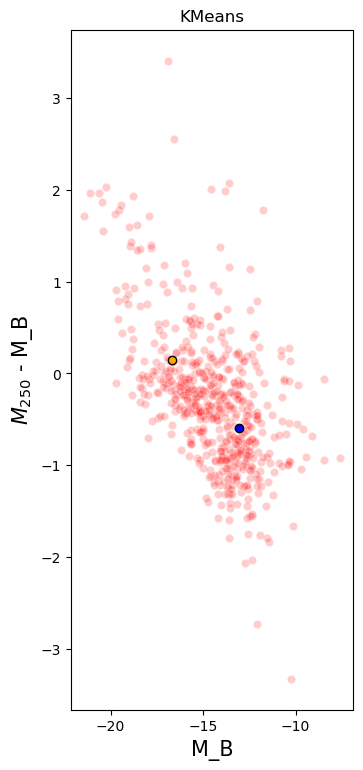

In [ ]:
fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ['orange','blue','green']

# KMeans
ax = fig.add_subplot(1, 3, 1)
ax.plot(M_B, M_250_B, "w", markerfacecolor='r', marker="o",alpha=0.2)
for k, col in zip(range(n_clusters), colors):
    print(k)
    #my_members = k_means_labels == k
    cluster_center = k_means_cluster_centers[k]
    print(cluster_center)
    ax.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=colors[k],
        markeredgecolor="k",
        markersize=6,
    )
ax.set_title("KMeans")
ax.set_xlabel('M_B',fontsize=15)
ax.set_ylabel('$M_{250}$ - M_B',fontsize=15)

### Getting optimal number of clusters

As we increase the number of clusters, the total variation in the set of clustering keeps decreasing. The extremum condition will be when there is only datapoint per cluster, then the variance = 0.
After a certain number of clusters, the variation doesn't reduce as fast. This point is referred to as the elbow point.


- ## Elbow Curve Method
WCSS is the sum of squared distance between each point and the centroid in a cluster. When we plot the WCSS with the K value, the plot looks like an Elbow. As the number of clusters increases, the WCSS value will start to decrease. WCSS value is largest when K = 1. When we analyze the graph we can see that the graph will rapidly change at a point and thus creating an elbow shape.

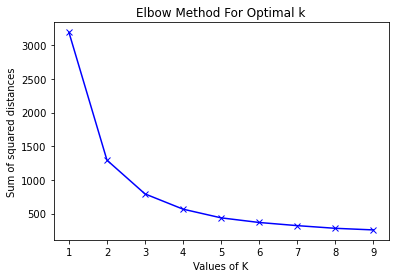

In [ ]:
Sum_of_squared_distances = []
K = range(1,10)
for num_clusters in K :
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(X)
    Sum_of_squared_distances.append(kmeans.inertia_)

plt.plot(K,Sum_of_squared_distances,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Sum of squared distances')
plt.title('Elbow Method For Optimal k')
plt.show()


- ## Silhouette analysis

### The Silhouette score/ coefficient is given by
## \begin{equation}
s = \frac{b-a}{max(a,b)}
\end{equation}

where

a is the mean distance between a data point and all other points in the same cluster, and,

b is the mean distance between the same data point and all other points in the next nearest cluster.

**The Silhouette Coefficient for a dataset is given as the mean of the Silhouette Coefficient of each data point.**

### The optimal number of clusters is the number of cluster at which Silhouette score is maximum.

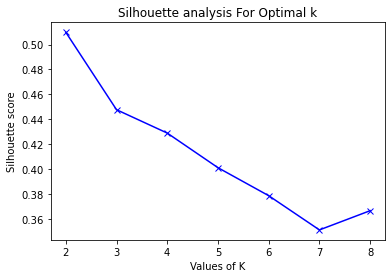

In [ ]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []
# initialise kmeans
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg.append(sklearn.metrics.silhouette_score(X, cluster_labels))
plt.plot(range_n_clusters,silhouette_avg,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 2, random_state = 42) #init = "k-means++"
y_kmeans = kmeans.fit_predict(X) #Compute cluster centers and predict cluster index for each sample. It returns labels

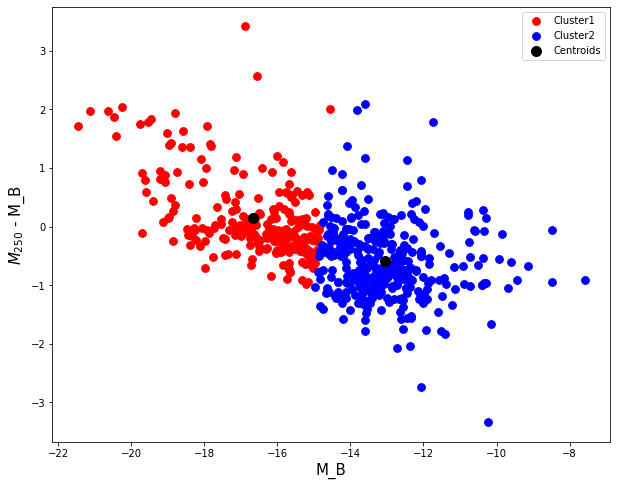

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 60, c = 'red', label = 'Cluster1')
#X[y_kmeans == 0, 0]: Selects the x-coordinates of the data points belonging to Cluster 1.
#X[y_kmeans == 0, 1]: Selects the y-coordinates of the same data points belonging to Cluster 1.
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
#plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')
plt.xlabel('M_B',fontsize=15)
plt.legend()
plt.ylabel('$M_{250}$ - M_B',fontsize=15)

plt.show()

In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import sklearn
kk=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/Fermi_GBM_catalog_15_8_22.txt',delimiter="|",skipinitialspace=True,usecols=['t90     ','flnc_band_epeak','flnc_band_alpha'])
#usecols=['t90     ','flnc_band_epeak','flnc_band_alpha']
kk.info()

T90 = np.array(kk['t90     '])
Epeak = np.array(kk['flnc_band_epeak'])
alpha = np.array(kk['flnc_band_alpha'])

v1 = ~(np.isnan(Epeak) | np.isnan(T90) | np.isnan(alpha))

T90=np.log10(T90[v1])
Epeak = np.log10(Epeak[v1])
alpha = alpha[v1]
X=[Epeak,T90]
X=np.array(X).T
print(X)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3340 entries, 0 to 3339
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   t90              3339 non-null   float64
 1   flnc_band_epeak  2308 non-null   float64
 2   flnc_band_alpha  2308 non-null   float64
dtypes: float64(3)
memory usage: 78.4 KB
[[2.28512347 0.63225478]
 [2.11001734 1.24074888]
 [2.35438315 1.11581014]
 ...
 [2.08344457 1.74470752]
 [1.90558775 0.87806198]
 [2.62484775 0.91338994]]


In [ ]:
n_clusters=2
kmeans_grb = KMeans(n_clusters, random_state=0).fit(X)
k_means_cluster_centers_grb = kmeans_grb.cluster_centers_
print(k_means_cluster_centers_grb)
k_means_labels_grb = sklearn.metrics.pairwise_distances_argmin(X, k_means_cluster_centers_grb)

[[ 2.14851172  1.47872982]
 [ 2.59087802 -0.07073128]]


Text(0, 0.5, 'log10(T90)')

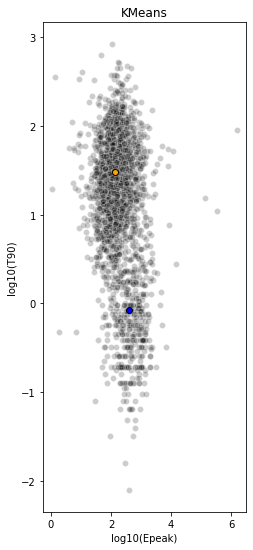

In [ ]:
fig = plt.figure(figsize=(10, 8))
fig.subplots_adjust(left=0.02, right=0.98, bottom=0.05, top=0.9)
colors = ['orange','blue']

# KMeans
ax = fig.add_subplot(1, 3, 1)
ax.plot(Epeak,T90, "w", markerfacecolor='k', marker="o",alpha=0.2)
for k, col in zip(range(n_clusters), colors):
    #my_members = k_means_labels_grb == k
    cluster_center = k_means_cluster_centers_grb[k]
    ax.plot(
        cluster_center[0],
        cluster_center[1],
        "o",
        markerfacecolor=colors[k],
        markeredgecolor="k",
        markersize=6,
    )
ax.set_title("KMeans")
ax.set_xlabel('log10(Epeak)')
ax.set_ylabel('log10(T90)')

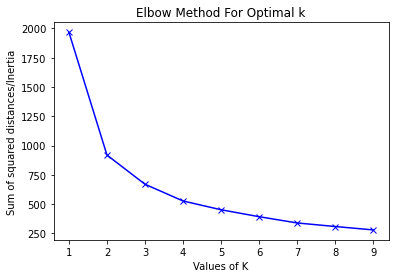

In [ ]:
Sum_of_squared_distances = []
K = range(1,10)
for num_clusters in K :
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(X)
    Sum_of_squared_distances.append(kmeans.inertia_)

plt.plot(K,Sum_of_squared_distances,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Sum of squared distances/Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()


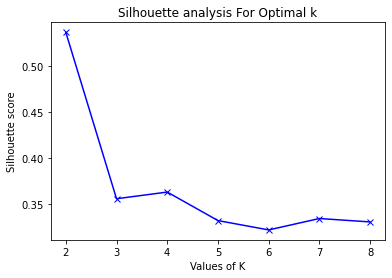

In [ ]:
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
silhouette_avg = []
# initialise kmeans
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg.append(sklearn.metrics.silhouette_score(X, cluster_labels))
plt.plot(range_n_clusters,silhouette_avg,'bx-')
plt.xlabel('Values of K')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters = 2,  random_state = 42) #init = "k-means++",
y_kmeans = kmeans.fit_predict(X)

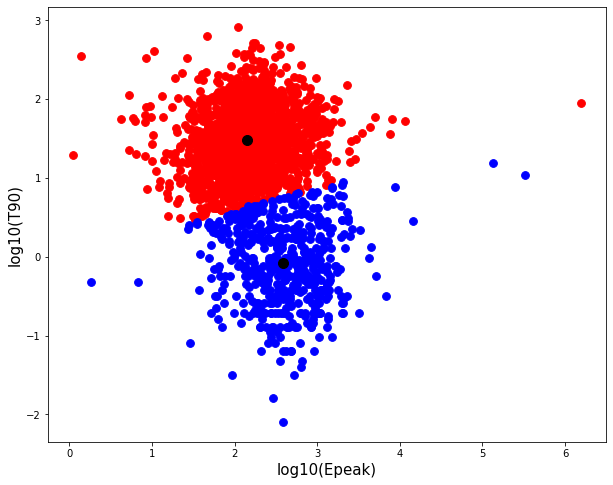

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 60, c = 'red', label = 'Cluster1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 60, c = 'blue', label = 'Cluster2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 60, c = 'green', label = 'Cluster3')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 100, c = 'black', label = 'Centroids')
plt.xlabel('log10(Epeak)',fontsize=15)
plt.ylabel('log10(T90)',fontsize=15)

plt.show()

## 2. Hierarchical Clustering

It is also an unsupervised clustering method. The clusters are build based on measuring dissimilarities between data.
There are two types of Hierarchical clustering:

- ### Agglomerative Clustering

It follows a bottom up approach where at first each data point is considered as its own cluster. Then, the clusters are built such that the datapoints have the shortest distance between them to create larger clusters. This step is repeated until one large cluster is formed containing all of the data points. It is Bottom up approach.

- ### Divisive Clustering

It is just the opposite of agglomerative clustering where the whole data is considered as one cluster and then divided further such as to reduce the variance. It is top down approach.

Hierarchical clustering requires us to decide on both a distance and linkage method. We will use euclidean distance and the Ward linkage method, which attempts to minimize the variance between clusters.

![dendrogram_example.jpg](attachment:dendrogram_example.jpg)

/Users/shabnamiyyani/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


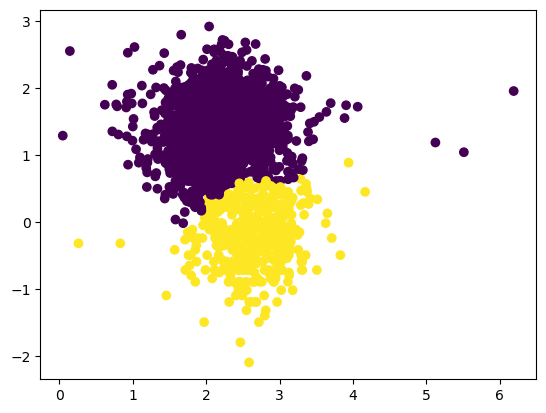

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering

x = Epeak
y = T90

data = list(zip(x, y))

hierarchical_cluster = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')
labels = hierarchical_cluster.fit_predict(data)

plt.scatter(x, y, c=labels)
plt.show()

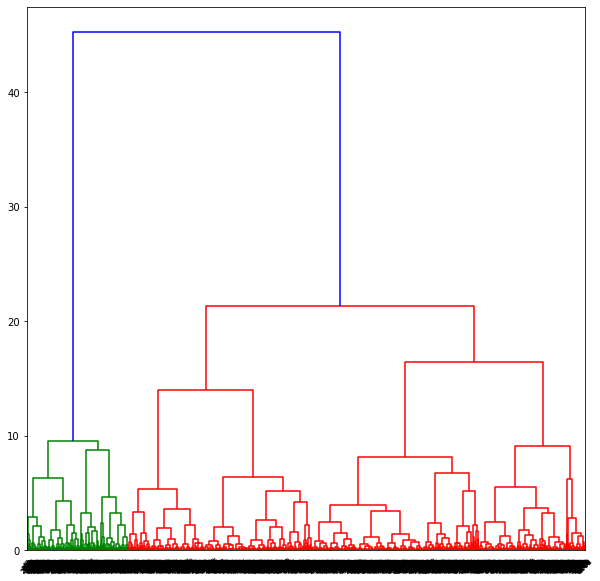

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
linkage_data = linkage(data, method='ward', metric='euclidean')
fig,ax = plt.subplots(figsize=(10,10))
dendrogram(linkage_data)
plt.xticks(rotation=45, fontweight='light',  fontsize='x-small',)
plt.show()

### This is referred to as the Dendogram or tree.
The ordinate of the dendrogram gives the distance at which each group merger occurs.

To get the optimal number of clusters for hierarchical clustering, we make use a dendogram which is tree-like chart that shows the sequences of merges or splits of clusters. If two clusters are merged, the dendrogram will join them in a graph and the height of the join will be the distance between those clusters.

we can set a threshold distance and draw a horizontal line (Generally, we try to set the threshold in such a way that it cuts the tallest vertical line). The number of clusters will be the number of vertical lines which are being intersected by the line drawn using the threshold.

The height axis of the dendrogram represents the distance between observations or clusters. The horizontal bars indicate the distance point at which the two clusters are merged.

### The cluster hierarchy resulting from this procedure depends strongly on the definition of the distance between a cluster and a new point which gives a measure of closeness or similarity.

(Ref: https://www.geeksforgeeks.org/ml-types-of-linkages-in-clustering/)
Four choices are there:    
## - single linkage: the distance to the closest member of the cluster is used. This is sometimes called the nearest-neighbor algorithm.
![Screenshot%202022-11-09%20at%209.35.00%20PM.png](attachment:Screenshot%202022-11-09%20at%209.35.00%20PM.png)

## - Complete Linkage: Here the distance to the furthest member of a group is used.
![Screenshot%202022-11-09%20at%209.36.53%20PM.png](attachment:Screenshot%202022-11-09%20at%209.36.53%20PM.png)

## - average linkage: It is arithmetic mean of all the distances between any datapoint in each cluster to any data point in all other clusters.
![Screenshot%202022-11-09%20at%209.56.58%20PM.png](attachment:Screenshot%202022-11-09%20at%209.56.58%20PM.png)

## - Ward’s minimum variance method: it is where the clusters to be merged are chosen to minimize the increase in the sum of intra-cluster summed squared distances.

## How is K-means different from Hierarchical clustering?

In K-means, the clustering is done into the specific number of clusters that is mentioned by the user. However, in Hierarchical clustering tells us pairwise what two datapoints are similar.

## - Gaussian Mixture Modelling   -- Multivariate Normal Clusters

In normal (Gaussian) mixture models, the data are assumed to be collected into k ellipsoidal clusters with multivariate normal (MVN) distributions. Each cluster has a mean vector and covariance matrix. The parameters of the normal mixture model are usually obtained by maximum likelihood estimation.

For GMM method, there should large enough data points available for clustering.

### Choosing the optimal number of clusters
Silhouette score can also be used for GMM to select the optimum number of clusters, but it works best when clusters are well-separated.

BIC/AIC are typically preferred for selecting the best GMM model.

A combination of silhouette score and BIC/AIC can give a more reliable decision.

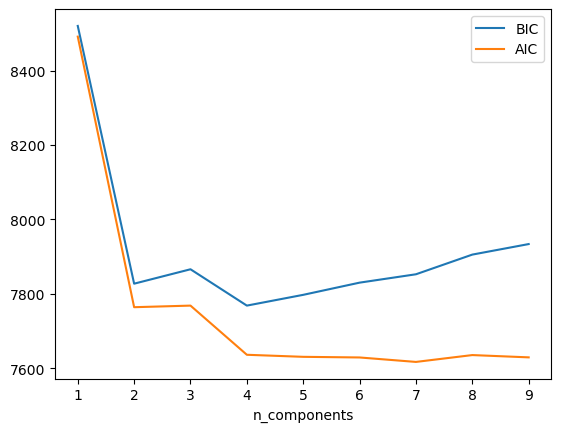

In [ ]:
from sklearn.mixture import GaussianMixture
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X) for n in n_components]
plt.plot(n_components, [m.bic(X) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

[[0.743 0.257]
 [0.993 0.007]
 [0.975 0.025]
 [0.993 0.007]
 [0.957 0.043]]


Text(0, 0.5, 'log10(T90)')

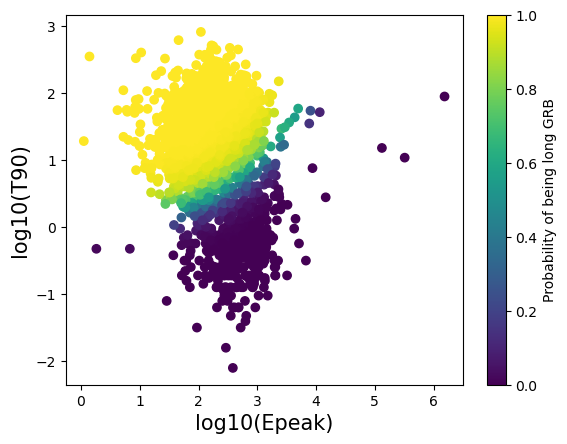

In [ ]:
gmm = GaussianMixture(n_components=2)
gmm.fit(X)
labels = gmm.predict(X)
probs = gmm.predict_proba(X)
print(probs[:5].round(3))
plt.scatter(X[:, 0], X[:, 1], c=probs[:,0].round(3), cmap='viridis');
plt.colorbar(label="Probability of being long GRB", orientation="vertical")
plt.xlabel('log10(Epeak)',fontsize=15)
plt.ylabel('log10(T90)',fontsize=15)

Text(0, 0.5, 'log10(T90)')

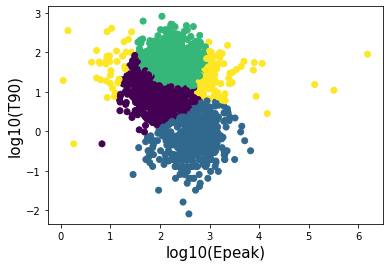

In [ ]:
gmm = GaussianMixture(n_components=4)
gmm.fit(X)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis');
plt.xlabel('log10(Epeak)',fontsize=15)
plt.ylabel('log10(T90)',fontsize=15)

In [ ]:
#Loading the dataset
import pandas as pd
kk=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/Magnitude_Color_galaxies.txt',delim_whitespace='  ',skipinitialspace=False,usecols=[0,1])
kk.info()

M_B = kk['V1'] # absolute magnitude of the galaxy in the blue band
M_250_B = kk['V2'] # the ultraviolet-to-blue color index of the galaxy
print(M_250_B)

X=np.array([M_B,M_250_B]).T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      572 non-null    float64
 1   V2      572 non-null    float64
dtypes: float64(2)
memory usage: 9.1 KB
0     -1.07
1      0.14
2      0.14
3     -0.10
4     -1.45
       ... 
567   -0.02
568   -0.85
569   -0.87
570    0.28
571   -0.98
Name: V2, Length: 572, dtype: float64


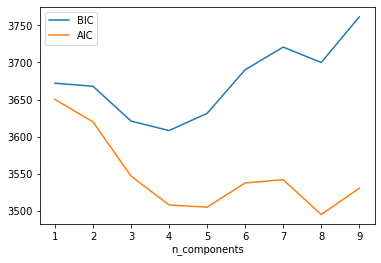

In [ ]:
from sklearn.mixture import GaussianMixture
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X) for n in n_components]
plt.plot(n_components, [m.bic(X) for m in models], label='BIC')
plt.plot(n_components, [m.aic(X) for m in models], label='AIC')
plt.legend(loc='best')
plt.xlabel('n_components');

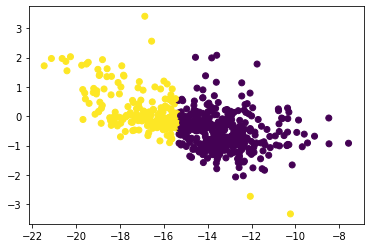

In [ ]:
gmm = GaussianMixture(n_components=2)
gmm.fit(X)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis');
# plt.xlabel('log10(Epeak)',fontsize=15)
# plt.ylabel('log10(T90)',fontsize=15)

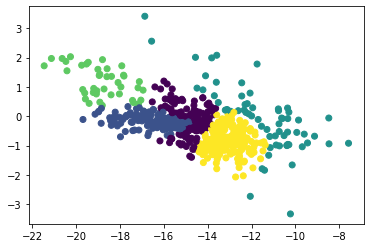

In [ ]:
gmm = GaussianMixture(n_components=5)
gmm.fit(X)
labels = gmm.predict(X)
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis');

## Supervised Clustering

The supervised learning allows the algorithm to learn from the training dataset the relationship between the input and output, and thereby make inferences on future input datasets.

Based on the given data sets, the machine learning problem is categorized into two types:
### 1. Classification:

If the training dataset has both input values and output values, and later on based on a given input asks the algorithm to predict the correspond output. Such a problem is a classification problem.

### K — nearest neighbor

K-Nearest Neighbours is one of the supervised learning classification algorithms. It is generally used in identifying  patterns, data mining and intrusion detection.
Its popularity is because of being non-parametric which means it does not make any underlying assumptions about the distribution of data (as opposed to other algorithms such as GMM, which assume a Gaussian distribution of the given data).

On the previously known clusters, lets say cluster A and B (trained dataset), we put in the new datapoint (d) which needs to be clustered. If the K =1, then we look for the nearest one neighbour datapoint and check to which cluster it belongs and assign the our unknown d to that cluster. If K = 10, it means we look for 10 nearest neighbouring datapoints and then among them see to which cluster does the majority of the nearest neighbours belong to and then assign d to that cluster.


In [ ]:
import pandas as pd
from sklearn import datasets
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import sklearn
kk=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/Fermi_GBM_catalog_15_8_22.txt',delimiter="|",skipinitialspace=True,usecols=['t90     ','flnc_band_epeak','flnc_band_alpha','fluence   '])
#usecols=['t90     ','flnc_band_epeak','flnc_band_alpha']
kk.info()

T90 = np.array(kk['t90     '])
Epeak = np.array(kk['flnc_band_epeak'])
alpha= np.array(kk['flnc_band_alpha'])
fluence = np.array(kk['fluence   '])

v1 = ~(np.isnan(Epeak) | np.isnan(T90) | np.isnan(alpha) | np.isnan(fluence))

T90=np.log10(T90[v1])
Epeak = np.log10(Epeak[v1])
alpha = alpha[v1]
fluence = np.log10(fluence[v1])
X_=[Epeak,T90]
X_=np.array(X_).T
#print(X)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3340 entries, 0 to 3339
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   t90              3339 non-null   float64
 1   fluence          3339 non-null   float64
 2   flnc_band_epeak  2308 non-null   float64
 3   flnc_band_alpha  2308 non-null   float64
dtypes: float64(4)
memory usage: 104.5 KB


In [ ]:
t90 =[]
a =[]
Epk =[]
flu =[]

t90_l =[]
a_l =[]
Epk_l =[]
flu_l =[]

for c, a_ in enumerate(alpha):
    if T90[c] <= np.log10(2.0):
        t90.append(T90[c])
        a.append(alpha[c])
        Epk.append(Epeak[c])
        flu.append(fluence[c])
    else:
        t90_l.append(T90[c])
        a_l.append(alpha[c])
        Epk_l.append(Epeak[c])
        flu_l.append(fluence[c])


target_id_s = np.zeros(len(t90)) # Short GRB label
target_id_l = np.ones(len(t90_l)) # Long GRB label
# X_short = np.array([t90,a,Epk,flu]).T
# X_long = np.array([t90_l,a_l,Epk_l,flu_l]).T
# GRBData = np.concatenate((X_short,X_long),axis=0)

X_short = np.array([t90,Epk]).T
X_long = np.array([t90_l,Epk_l]).T
GRBData = np.concatenate((X_short,X_long),axis=0)

Tar = np.concatenate((target_id_s,target_id_l),axis=0)

#Creating a dictionary
GRB = {'Data': GRBData, 'Target_ID':Tar, 'Target_names':['Short GRB','Long GRB']}

In [ ]:
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier

# Declare an of the KNN classifier class with the value with neighbors.
knn = KNeighborsClassifier(n_neighbors=50)

# Fit the model with training data and target values
knn.fit(GRB['Data'], GRB['Target_ID'])

# Provide data whose class labels are to be predicted
X = [
    [np.log10(2),np.log10(1000)],
    [np.log10(5),np.log10(100)]
]

# Prints the data provided
print(X)

# Store predicted class labels of X
prediction = knn.predict(X)

# Prints the predicted class labels of X
print(prediction)

[[0.3010299956639812, 3.0], [0.6989700043360189, 2.0]]
[0. 1.]


In [ ]:
# from sklearn.mixture import GaussianMixture
# gmm = GaussianMixture(n_components=2)
# gmm.fit(X_)
# labels = gmm.predict(X_)
# probs = gmm.predict_proba(X_)
# print(probs[:5].round(3))
# plt.scatter(X_[:, 0], X_[:, 1], c=probs[:,0].round(3), cmap='viridis');
# plt.plot(np.log10(1000), np.log10(2), 'ro');
# plt.plot(np.log10(100), np.log10(5), 'bo');
# plt.colorbar(label="Probability of being long GRB", orientation="vertical")
# plt.xlabel('log10(Epeak)',fontsize=15)
# plt.ylabel('log10(T90)',fontsize=15)

# Classification of SDSS point sources into potential white dwarfs and Quasars

In [ ]:
# Input Dataset
pt_src=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/SDSS_Pointsources.csv',delimiter=",",skipinitialspace=True,usecols=[0,1,2,3,4,5,6])
pt_src.info()
u = pt_src['psfmag_u']
g = pt_src['psfmag_g']
r = pt_src['psfmag_r']
i = pt_src['psfmag_i']
z = pt_src['psfmag_z']
ra = pt_src['ra']
dec = pt_src['dec']

#print(pt_src)

Input_X = np.array([u,g,r,i,z]).T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7603 entries, 0 to 7602
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   psfmag_u  7603 non-null   float64
 1   psfmag_g  7603 non-null   float64
 2   psfmag_r  7603 non-null   float64
 3   psfmag_i  7603 non-null   float64
 4   psfmag_z  7603 non-null   float64
 5   ra        7603 non-null   float64
 6   dec       7603 non-null   float64
dtypes: float64(7)
memory usage: 415.9 KB


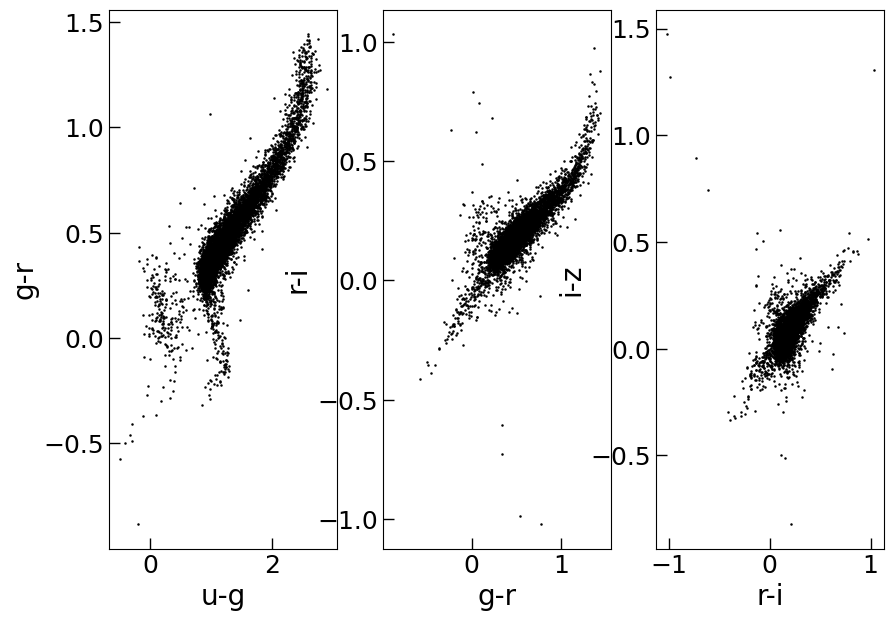

In [ ]:
fig_ug,(ax2,ax3,ax4) = plt.subplots(1,3,figsize =(10, 7))
ax2.plot(np.subtract(u,g),np.subtract(g,r),'ko',markersize=0.8)
ax2.tick_params(axis='both',which='both', width=1,direction='in')
ax2.tick_params(which='major', length=8)
ax2.tick_params(which='minor', length=4)
ax2.tick_params(axis='x', labelsize=18)
ax2.tick_params(axis='y', labelsize=18)
ax2.set_ylabel('g-r',fontsize=20)
ax2.set_xlabel('u-g',fontsize=20)

ax3.plot(np.subtract(g,r),np.subtract(r,i),'ko',markersize=0.8)
ax3.tick_params(axis='both',which='both', width=1,direction='in')
ax3.tick_params(which='major', length=8)
ax3.tick_params(which='minor', length=4)
ax3.tick_params(axis='x', labelsize=18)
ax3.tick_params(axis='y', labelsize=18)
ax3.set_ylabel('r-i',fontsize=20)
ax3.set_xlabel('g-r',fontsize=20)

ax4.plot(np.subtract(r,i),np.subtract(i,z),'ko',markersize=0.8)
ax4.tick_params(axis='both',which='both', width=1,direction='in')
ax4.tick_params(which='major', length=8)
ax4.tick_params(which='minor', length=4)
ax4.tick_params(axis='x', labelsize=18)
ax4.tick_params(axis='y', labelsize=18)
ax4.set_ylabel('i-z',fontsize=20)
ax4.set_xlabel('r-i',fontsize=20)


plt.show()

In [ ]:
# White Dwarf Training dataset
wd=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/TD_White_Dwarf.txt',delimiter=";",skipinitialspace=True,usecols=[0,1,2,3,4,5,6,7,8,9,10,11])
wd.info()

u_wd = wd['umag']
g_wd = wd['gmag']
r_wd = wd['rmag']
i_wd = wd['imag']
z_wd = wd['zmag']
ra_wd = wd['RAJ2000']
dec_wd = wd['RAJ2000']

#print(wd)
#print(len(u_wd))
v2 = ~(np.isnan(u_wd) | np.isnan(g_wd) | np.isnan(r_wd) | np.isnan(i_wd) | np.isnan(z_wd))

u_wd=u_wd[v2]
g_wd = g_wd[v2]
r_wd = r_wd[v2]
i_wd = i_wd[v2]
z_wd = z_wd[v2]

target_id_wd = np.zeros(len(u_wd))
X_wd = np.array([u_wd,g_wd,r_wd,i_wd,z_wd]).T




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9960 entries, 0 to 9959
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   SpClass  9960 non-null   object 
 1   WD       2724 non-null   object 
 2   SDSS     9960 non-null   object 
 3   pm       9199 non-null   float64
 4   pmPA     9199 non-null   float64
 5   umag     9948 non-null   float64
 6   gmag     9948 non-null   float64
 7   rmag     9948 non-null   float64
 8   imag     9948 non-null   float64
 9   zmag     9948 non-null   float64
 10  RAJ2000  9960 non-null   float64
 11  DEJ2000  9960 non-null   float64
dtypes: float64(9), object(3)
memory usage: 933.9+ KB


In [ ]:
#Quasars Training Dataset
qua=pd.read_csv('/Users/shabnamiyyani/Gamma_ray_burst Dropbox/Shabnam Iyyani/Teaching_Notes_IISER/PHY5132:6132_Statistical_and_data_analysis_in_Physical_Sciences/DataSets/TD_quasars.txt',sep='\s+',skiprows=1, names=list(range(54)))
qua.info()

u_qua = qua[5]
g_qua = qua[6]
r_qua = qua[7]
i_qua = qua[8]
z_qua = qua[9]
ra_qua = qua[1]
dec_qua = qua[2]

X_qua = np.array([u_qua,g_qua,r_qua,i_qua,z_qua]).T
target_id_qua = np.ones(len(u_qua))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16713 entries, 0 to 16712
Data columns (total 54 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       16713 non-null  object 
 1   1       16713 non-null  float64
 2   2       16713 non-null  float64
 3   3       16713 non-null  float64
 4   4       16713 non-null  int64  
 5   5       16713 non-null  float64
 6   6       16713 non-null  float64
 7   7       16713 non-null  float64
 8   8       16713 non-null  float64
 9   9       16713 non-null  float64
 10  10      16713 non-null  float64
 11  11      16713 non-null  float64
 12  12      16713 non-null  float64
 13  13      16713 non-null  float64
 14  14      16713 non-null  float64
 15  15      16713 non-null  float64
 16  16      16713 non-null  float64
 17  17      16713 non-null  float64
 18  18      16713 non-null  float64
 19  19      16713 non-null  float64
 20  20      16713 non-null  float64
 21  21      16713 non-null  float64
 22

In [ ]:
#Putting together the training datasets
TD = np.concatenate((X_qua,X_wd),axis=0)

Tar_sdss = np.concatenate((target_id_qua,target_id_wd),axis=0)


TrainingData = {'Data': TD, 'Target_ID':Tar_sdss, 'Target_names':['Quasar','White Dwarf']}

In [ ]:
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier


# Declare an of the KNN classifier class with the value with neighbors.
knn = KNeighborsClassifier(n_neighbors=1000)

# Fit the model with training data and target values
knn.fit(TrainingData['Data'], TrainingData['Target_ID'])

# Provide data whose class labels are to be predicted
X = Input_X

# Prints the data provided
#print(X)

# Store predicted class labels of X
prediction = knn.predict(X)

# Prints the predicted class labels of X
print(prediction)

[0. 0. 0. ... 0. 0. 0.]


In [ ]:
print(len(prediction), len(TrainingData['Data']))

7603 26661


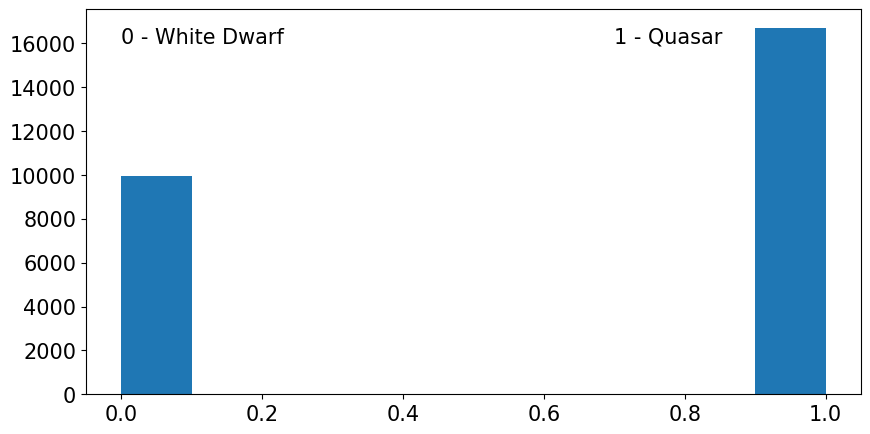

In [ ]:
fig = plt.figure(figsize = (10, 5))

# creating the bar plot
plt.hist(TrainingData['Target_ID'])
plt.text(0,16000,'0 - White Dwarf',fontsize=15)
plt.text(0.7,16000,'1 - Quasar',fontsize=15)

plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.show()

### 2. Regression:

On the other hand, if the training dataset has continous numerical values of x and y. At first a relationship is established between the X and Y which later on is used to predict Y for any given X is referred to as a regression problem.

In [ ]:
# fig_scatter,ax2 = plt.subplots(figsize =(10, 7))
# ax2.plot(Epeak,np.log10(np.divide(10**(fluence),T90)),'ko')
# #ax2.set_xscale('log')
# #ax2.set_yscale('log')
# #plt.ylim([-5,5])
# ax2.tick_params(axis='both',which='both', width=1,direction='in')
# ax2.tick_params(which='major', length=8)
# ax2.tick_params(which='minor', length=4)
# ax2.tick_params(axis='x', labelsize=18)
# ax2.tick_params(axis='y', labelsize=18)
# ax2.set_ylabel('alpha',fontsize=20)
# ax2.set_xlabel('Epeak (keV)',fontsize=20)
# plt.show()